In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
path = '/content/drive/MyDrive/bank.csv'
df = pd.read_csv(path)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [6]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [9]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [10]:
df.shape

(11162, 17)

In [12]:
df.isnull()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11158,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11159,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11160,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [13]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
11157,False
11158,False
11159,False
11160,False


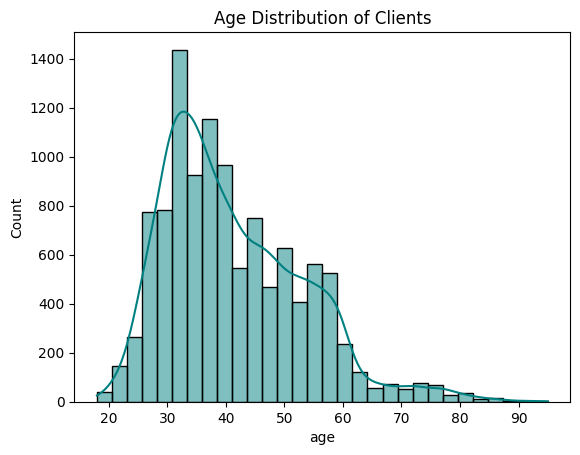

In [14]:
sns.histplot(df['age'], bins=30, kde=True, color='teal')
plt.title('Age Distribution of Clients')
plt.show()

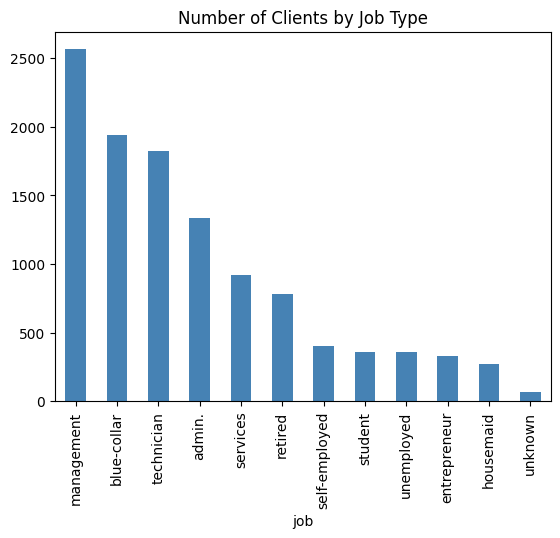

In [15]:
df['job'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Number of Clients by Job Type')
plt.show()

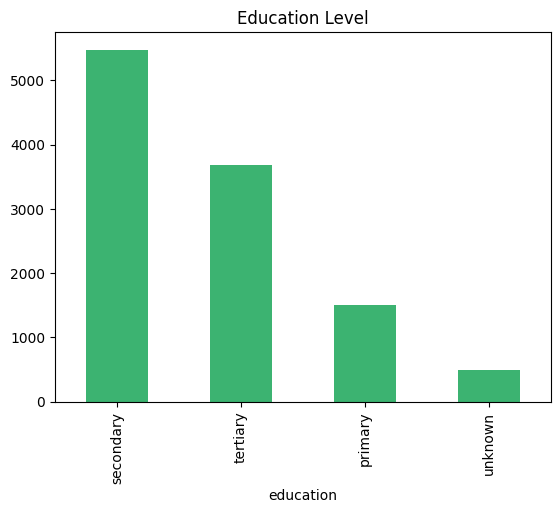

In [16]:
df['education'].value_counts().plot(kind='bar', color='mediumseagreen')
plt.title('Education Level')
plt.show()

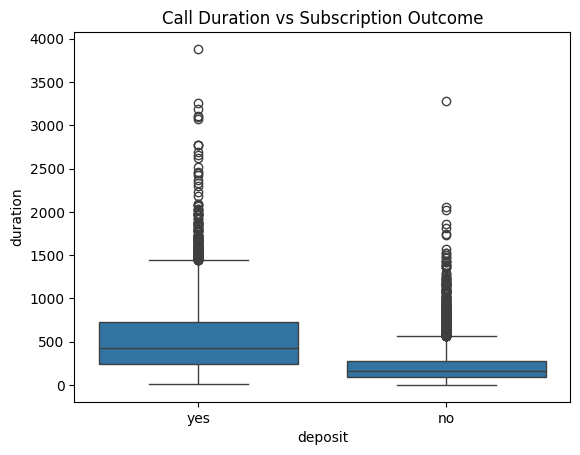

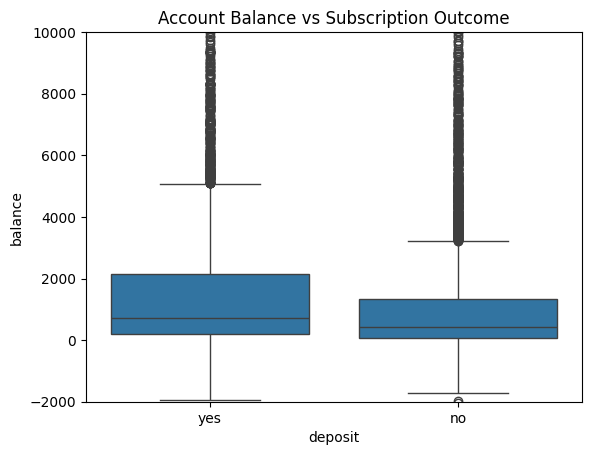

In [18]:
sns.boxplot(x='deposit', y='duration', data=df)
plt.title('Call Duration vs Subscription Outcome')
plt.show()

sns.boxplot(x='deposit', y='balance', data=df)
plt.ylim(-2000, 10000)
plt.title('Account Balance vs Subscription Outcome')
plt.show()

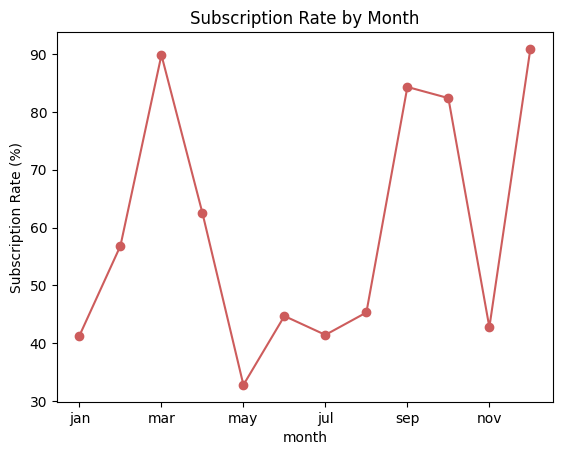

In [20]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_rate = df.groupby('month')['deposit'].apply(lambda x: (x == 'yes').mean()).mul(100).reindex(month_order)
month_rate.plot(kind='line', marker='o', color='indianred')
plt.title('Subscription Rate by Month')
plt.ylabel('Subscription Rate (%)')
plt.show()

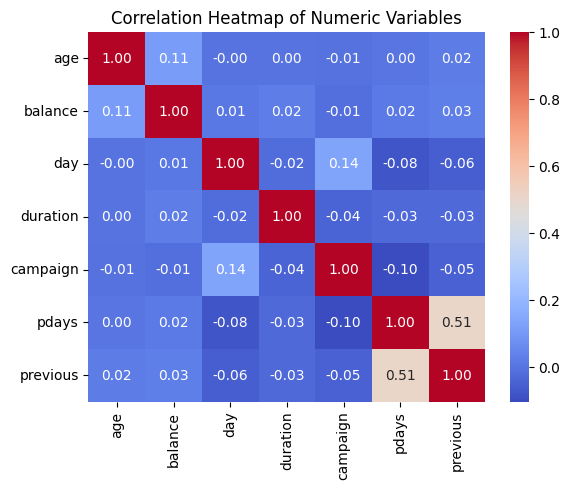

In [22]:
import numpy as np
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

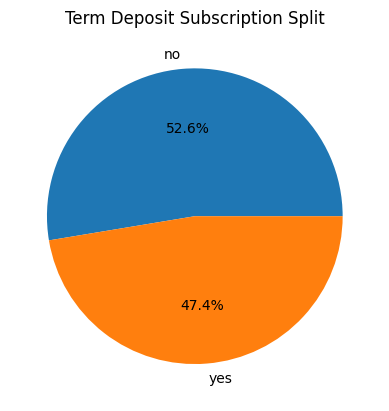

In [23]:
df['deposit'].value_counts().plot(kind='pie', autopct='%1.1f%%', ylabel='', title='Term Deposit Subscription Split')
plt.show()